# 2. Comprendre le modèle U-Net de super-résolution guidée

Ce notebook explique l'architecture du modèle et sa fonction de perte, avec des **données synthétiques** générées à la volée (pas besoin d'attendre un vrai dataset pour comprendre comment ça marche).

On va :
1. Construire le U-Net bloc par bloc et observer les formes des tenseurs à chaque étape.
2. Comprendre la fonction de perte multi-objectif (pixel + cohérence).
3. Lancer un mini entraînement sur des données jouets pour voir la loss diminuer.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)

## 2.1 Bloc de base : `DoubleConv`

Chaque étage du U-Net applique deux convolutions 3x3 (+ BatchNorm + ReLU). C'est le "bloc Lego" qu'on répète partout.

In [2]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

# Test rapide : un bloc qui passe de 7 canaux à 64
test_block = DoubleConv(7, 64)
dummy_input = torch.randn(1, 7, 256, 256)
dummy_output = test_block(dummy_input)
print("Entrée :", dummy_input.shape)
print("Sortie :", dummy_output.shape, "-> même H,W, mais plus de canaux (plus de 'features' apprises)")

Entrée : torch.Size([1, 7, 256, 256])
Sortie : torch.Size([1, 64, 256, 256]) -> même H,W, mais plus de canaux (plus de 'features' apprises)


## 2.2 Le U-Net complet, avec impression des formes à chaque étage

L'idée du U-Net : on **descend** (encoder, MaxPool) en perdant de la résolution spatiale mais en gagnant en richesse de représentation, puis on **remonte** (decoder, ConvTranspose) en réutilisant les détails perdus grâce aux *skip connections* (les flèches horizontales du schéma en U).

> **Note pédagogique — bug corrigé par rapport à la spec d'origine :**
> Le document de spécification initial ne comptait que 2 étages de descente avant le bottleneck, mais 2 étages de remontée avec des skip-connections qui supposaient une descente supplémentaire. Résultat : les tailles spatiales ne se recollaient pas (`torch.cat` plantait). On **ajoute un 3e étage de descente/remontée** pour que tout soit cohérent, et surtout pour que la sortie ait bien la même résolution (H, W) que l'entrée (indispensable pour calculer la pixel loss).

In [3]:
class GuidedSuperResUNet(nn.Module):
    def __init__(self, in_channels=7, out_channels=1, verbose=False):
        super().__init__()
        self.verbose = verbose

        # Encoder (3 etages de descente, corrige)
        self.inc = DoubleConv(in_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))  # bottleneck

        # Decoder (3 etages de remontee symetriques)
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)  # 256 (up) + 256 (skip x3)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)  # 128 (up) + 128 (skip x2)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)  # 64 (up) + 64 (skip x1)

        self.outc = nn.Conv2d(64, out_channels, kernel_size=1)

    def _log(self, name, tensor):
        if self.verbose:
            print(f"{name:20s} -> {tuple(tensor.shape)}")

    def forward(self, x):
        self._log("input", x)

        x1 = self.inc(x)
        self._log("encoder x1 (64 ch)", x1)

        x2 = self.down1(x1)
        self._log("encoder x2 (128 ch)", x2)

        x3 = self.down2(x2)
        self._log("encoder x3 (256 ch)", x3)

        b = self.down3(x3)
        self._log("bottleneck (512 ch)", b)

        t1 = self.up1(b)
        t1 = torch.cat([t1, x3], dim=1)  # skip connection avec x3
        t1 = self.conv_up1(t1)
        self._log("decoder t1 (256 ch)", t1)

        t2 = self.up2(t1)
        t2 = torch.cat([t2, x2], dim=1)  # skip connection avec x2
        t2 = self.conv_up2(t2)
        self._log("decoder t2 (128 ch)", t2)

        t3 = self.up3(t2)
        t3 = torch.cat([t3, x1], dim=1)  # skip connection avec x1
        t3 = self.conv_up3(t3)
        self._log("decoder t3 (64 ch)", t3)

        out = self.outc(t3)
        self._log("output (1 ch = LST)", out)

        return out

model = GuidedSuperResUNet(in_channels=7, out_channels=1, verbose=True)
dummy_x = torch.randn(2, 7, 256, 256)  # batch de 2 patchs
_ = model(dummy_x)

input                -> (2, 7, 256, 256)


encoder x1 (64 ch)   -> (2, 64, 256, 256)


encoder x2 (128 ch)  -> (2, 128, 128, 128)
encoder x3 (256 ch)  -> (2, 256, 64, 64)


bottleneck (512 ch)  -> (2, 512, 32, 32)


decoder t1 (256 ch)  -> (2, 256, 64, 64)


decoder t2 (128 ch)  -> (2, 128, 128, 128)


decoder t3 (64 ch)   -> (2, 64, 256, 256)
output (1 ch = LST)  -> (2, 1, 256, 256)


Remarque : la sortie a maintenant bien la **même taille spatiale (256x256)** que l'entrée, avec un seul canal (la température). C'est normal : ce n'est pas un modèle de classification, mais un modèle de régression pixel par pixel (souvent appelé "image-to-image").

## 2.3 La fonction de perte multi-objectif

Trois composantes :

1. **Pixel Loss (L1)** : la prédiction doit être proche de la vérité terrain, pixel par pixel.
2. **Consistency Loss** : si on dégrade notre prédiction à 100m (average pooling 10x10), on doit retrouver la vraie image Landsat à 100m. C'est **la contrainte la plus importante** : elle ancre le modèle dans la réalité physique mesurée, même si on ne connaît jamais la "vraie" LST à 10m.
3. (Dans la version complète : SSIM Loss pour préserver les structures/contrastes locaux)

$$\mathcal{L}_{total} = \mathcal{L}_{L1} + 0.5 \cdot \mathcal{L}_{consistency}$$

In [4]:
def compute_losses(y_hat, y_true_100m_equivalent):
    """
    y_hat : prédiction du modèle à 10m, (B, 1, H, W)
    y_true_100m_equivalent : la seule vérité qu'on a réellement, dégradée à 100m, (B, 1, H/10, W/10)
    """
    y_hat_downscaled = F.avg_pool2d(y_hat, kernel_size=10, stride=10)
    loss_consistency = F.mse_loss(y_hat_downscaled, y_true_100m_equivalent)
    return loss_consistency

# Exemple avec nos données jouets
y_true_100m = F.avg_pool2d(torch.randn(2, 1, 256, 256) + 25, kernel_size=10, stride=10)
y_hat_demo = model(dummy_x)
loss_demo = compute_losses(y_hat_demo, y_true_100m)
print("Loss de cohérence (avant entraînement, donc élevée) :", loss_demo.item())

input                -> (2, 7, 256, 256)


encoder x1 (64 ch)   -> (2, 64, 256, 256)


encoder x2 (128 ch)  -> (2, 128, 128, 128)
encoder x3 (256 ch)  -> (2, 256, 64, 64)


bottleneck (512 ch)  -> (2, 512, 32, 32)


decoder t1 (256 ch)  -> (2, 256, 64, 64)


decoder t2 (128 ch)  -> (2, 128, 128, 128)


decoder t3 (64 ch)   -> (2, 64, 256, 256)
output (1 ch = LST)  -> (2, 1, 256, 256)
Loss de cohérence (avant entraînement, donc élevée) : 626.4442749023438


## 2.4 Mini entraînement sur données synthétiques

On génère un petit jeu de données jouet (features corrélées à une température simulée) et on entraîne le modèle pendant quelques dizaines d'itérations pour **voir la loss descendre** — l'objectif ici est de comprendre la mécanique d'entraînement, pas d'obtenir un modèle utilisable.

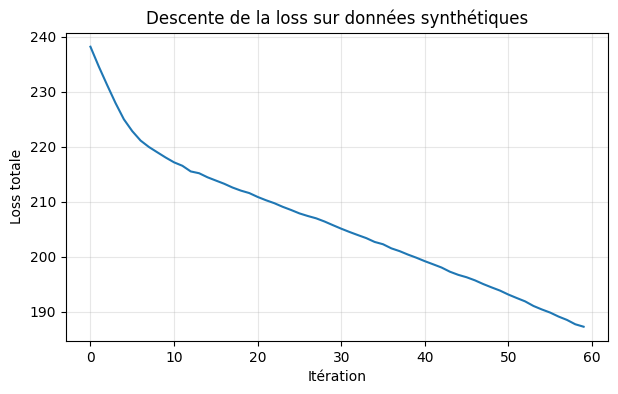

Loss initiale : 238.178 -> Loss finale : 187.252


In [5]:
def generate_synthetic_batch(batch_size=4, H=64, W=64):
    xx, yy = torch.meshgrid(torch.linspace(-1, 1, W), torch.linspace(-1, 1, H), indexing="xy")
    batch_X, batch_Y = [], []
    for _ in range(batch_size):
        offset_x, offset_y = torch.rand(2) * 0.6 - 0.3
        dist = torch.sqrt((xx - offset_x) ** 2 + (yy - offset_y) ** 2)
        bati = torch.clamp(1 - dist, 0, 1) ** 1.5
        veg = torch.clamp(1 - bati + 0.2 * torch.rand(H, W), 0, 1)

        red = 0.5 * bati + 0.1 * (1 - veg)
        nir = 0.8 * veg + 0.1 * (1 - bati)
        green = 0.4 * veg + 0.2 * bati
        swir = 0.6 * bati + 0.1 * veg
        blue = 0.3 * (1 - veg)
        ndvi = (nir - red) / (nir + red + 1e-6)
        ndwi = (green - nir) / (green + nir + 1e-6)

        x = torch.stack([red, green, blue, ndvi, ndwi, veg, bati], dim=0)
        y = 22 + 8 * bati - 3 * veg
        y = y.unsqueeze(0)

        batch_X.append(x)
        batch_Y.append(y)

    return torch.stack(batch_X), torch.stack(batch_Y)

# Petit U-Net adapte a des patchs 64x64 pour aller vite
# (64 = 2^6, on a 3 MaxPool2d(2) dans l'encoder -> resolution mini 8x8, ca passe)
model_demo = GuidedSuperResUNet(in_channels=7, out_channels=1, verbose=False)
optimizer = torch.optim.AdamW(model_demo.parameters(), lr=1e-3)

losses = []
n_steps = 60

for step in range(n_steps):
    x, y = generate_synthetic_batch(batch_size=8, H=64, W=64)

    y_hat = model_demo(x)
    loss_pixel = F.l1_loss(y_hat, y)

    y_hat_down = F.avg_pool2d(y_hat, kernel_size=8, stride=8)
    y_down = F.avg_pool2d(y, kernel_size=8, stride=8)
    loss_consistency = F.mse_loss(y_hat_down, y_down)

    total_loss = loss_pixel + 0.5 * loss_consistency

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    losses.append(total_loss.item())

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Itération")
plt.ylabel("Loss totale")
plt.title("Descente de la loss sur données synthétiques")
plt.grid(alpha=0.3)
plt.show()

print(f"Loss initiale : {losses[0]:.3f} -> Loss finale : {losses[-1]:.3f}")

## 2.5 Visualiser une prédiction

Comparons une prédiction du mini-modèle entraîné avec la vérité terrain, sur un nouveau patch synthétique.

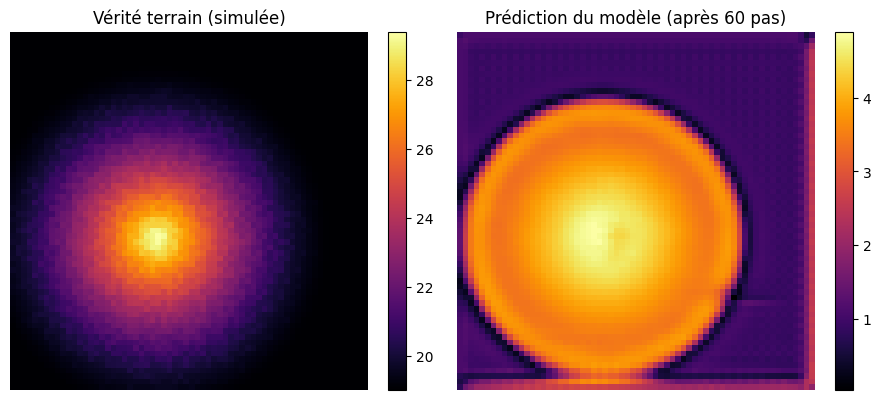

In [6]:
model_demo.eval()
with torch.no_grad():
    x_test, y_test = generate_synthetic_batch(batch_size=1, H=64, W=64)
    y_pred = model_demo(x_test)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im0 = axes[0].imshow(y_test[0, 0], cmap="inferno")
axes[0].set_title("Vérité terrain (simulée)")
im1 = axes[1].imshow(y_pred[0, 0], cmap="inferno")
axes[1].set_title("Prédiction du modèle (après 60 pas)")
for ax, im in zip(axes, [im0, im1]):
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## À retenir

- Le U-Net encode (perd du détail spatial, gagne en abstraction) puis décode (retrouve le détail grâce aux *skip connections*).
- La sortie est une carte de température, pas une classification.
- La loss combine fidélité pixel-à-pixel **et** cohérence avec la seule vérité mesurable réellement (Landsat à 100m) — c'est ce qui permet au modèle d'halluciner des détails plausibles à 10m sans jamais avoir vu de vraie image à cette résolution.
- Sur le vrai projet, remplace `generate_synthetic_batch` par le `NantesICUDataset` du notebook 1 (lecture de fichiers raster réels) et utilise `pytorch_lightning.Trainer` pour l'entraînement complet (avec GPU, mixed precision, logging, etc.).